学生机器为轻薄本，部分代码做了极轻量化处理，导致结果可能有偏差或者未能成功运行

=== 实验组：CrossEntropyLoss ===
Epoch 01/20 | Train Loss: 0.2900, Acc: 0.9134, KL: 0.2900 | Val Loss: 0.1427, Acc: 0.9553, KL: 0.1427
Epoch 02/20 | Train Loss: 0.1215, Acc: 0.9629, KL: 0.1215 | Val Loss: 0.1070, Acc: 0.9679, KL: 0.1070
Epoch 03/20 | Train Loss: 0.0874, Acc: 0.9725, KL: 0.0874 | Val Loss: 0.0902, Acc: 0.9717, KL: 0.0902
Epoch 04/20 | Train Loss: 0.0630, Acc: 0.9798, KL: 0.0630 | Val Loss: 0.1097, Acc: 0.9655, KL: 0.1097
Epoch 05/20 | Train Loss: 0.0512, Acc: 0.9832, KL: 0.0512 | Val Loss: 0.0957, Acc: 0.9724, KL: 0.0957
Epoch 06/20 | Train Loss: 0.0417, Acc: 0.9867, KL: 0.0417 | Val Loss: 0.0826, Acc: 0.9771, KL: 0.0826
Epoch 07/20 | Train Loss: 0.0336, Acc: 0.9888, KL: 0.0336 | Val Loss: 0.0826, Acc: 0.9764, KL: 0.0825
Epoch 08/20 | Train Loss: 0.0311, Acc: 0.9895, KL: 0.0311 | Val Loss: 0.0996, Acc: 0.9741, KL: 0.0992
Epoch 09/20 | Train Loss: 0.0249, Acc: 0.9919, KL: 0.0249 | Val Loss: 0.1056, Acc: 0.9744, KL: 0.1051
Epoch 10/20 | Train Loss: 0.0233, Acc: 0.9921, KL: 0.

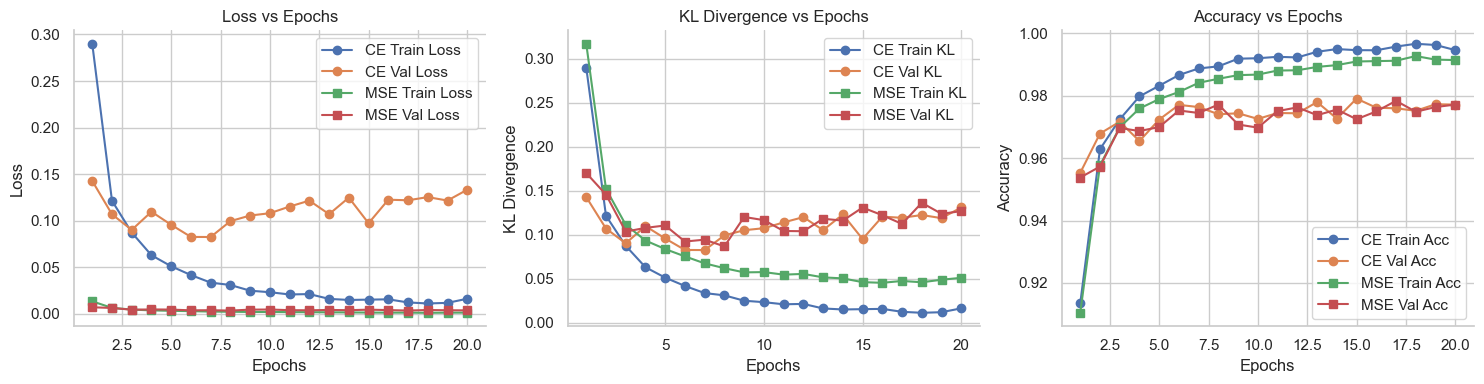


=== 测试集最终性能对比 ===
CrossEntropyLoss | Loss: 0.1191, Acc: 0.9754, KL: 0.1185
MSELoss          | Loss: 0.0037, Acc: 0.9780, KL: 0.1185


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ---------------------- 1. 超参数设置 ----------------------
batch_size = 64
lr = 0.001
epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#划分训练集（50000）和验证集（10000）
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST 均值方差
    transforms.Lambda(lambda x: x.view(-1))       # 展平成 784 维向量
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_set, val_set = random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#网络结构：784 -> 128 -> 64 -> 10 的全连接网络
#激活函数：ReLU，sigmoid等
#输出层：无激活（Logits）或接入softmax层
class Net(nn.Module):
    def __init__(self, use_softmax=False):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.use_softmax = use_softmax

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        if self.use_softmax:
            x = torch.softmax(x, dim=1)
        return x

# ---------------------- 训练+评估函数 ----------------------
def compute_kl_divergence(p, q):
    q = q + 1e-10
    p = p + 1e-10
    return torch.sum(p * torch.log(p / q), dim=1).mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device, use_mse=False):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    total_kl = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)

        if use_mse:
            # 标签转为 one-hot
            y_onehot = torch.zeros_like(logits).scatter_(1, y.unsqueeze(1), 1.0)
            loss = criterion(logits, y_onehot)
            # 计算 KL 散度
            kl = compute_kl_divergence(y_onehot, logits)
        else:
            # CrossEntropyLoss 输入是 logits，标签是 class index
            loss = criterion(logits, y)
            # 计算 KL 散度：需要把 logits 转成 softmax 概率
            probs = torch.softmax(logits, dim=1)
            y_onehot = torch.zeros_like(probs).scatter_(1, y.unsqueeze(1), 1.0)
            kl = compute_kl_divergence(y_onehot, probs)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_kl += kl * x.size(0)
        _, predicted = logits.max(1)
        correct += (predicted == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total
    avg_kl = total_kl / total
    return avg_loss, avg_acc, avg_kl

def test(model, loader, criterion, device, use_mse=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    total_kl = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)

            if use_mse:
                y_onehot = torch.zeros_like(logits).scatter_(1, y.unsqueeze(1), 1.0)
                loss = criterion(logits, y_onehot)
                kl = compute_kl_divergence(y_onehot, logits)
            else:
                loss = criterion(logits, y)
                probs = torch.softmax(logits, dim=1)
                y_onehot = torch.zeros_like(probs).scatter_(1, y.unsqueeze(1), 1.0)
                kl = compute_kl_divergence(y_onehot, probs)

            total_loss += loss.item() * x.size(0)
            total_kl += kl * x.size(0)
            _, predicted = logits.max(1)
            correct += (predicted == y).sum().item()
            total += x.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total
    avg_kl = total_kl / total
    return avg_loss, avg_acc, avg_kl

# ---------------------- 5. 实验组（CrossEntropyLoss） ----------------------
print("=== 实验组：CrossEntropyLoss ===")
model_ce = Net(use_softmax=False).to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.Adam(model_ce.parameters(), lr=lr)

ce_train_loss, ce_train_acc, ce_train_kl = [], [], []
ce_val_loss, ce_val_acc, ce_val_kl = [], [], []

for epoch in range(epochs):
    tr_loss, tr_acc, tr_kl = train_one_epoch(model_ce, train_loader, criterion_ce, optimizer_ce, device, use_mse=False)
    val_loss, val_acc, val_kl = test(model_ce, val_loader, criterion_ce, device, use_mse=False)

    ce_train_loss.append(tr_loss)
    ce_train_acc.append(tr_acc)
    ce_train_kl.append(tr_kl)
    ce_val_loss.append(val_loss)
    ce_val_acc.append(val_acc)
    ce_val_kl.append(val_kl)

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}, KL: {tr_kl:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, KL: {val_kl:.4f}")

# ---------------------- 6. 对照组（MSELoss） ----------------------
print("\n=== 对照组：MSELoss ===")
# MSE 时，网络输出最好也经过 softmax，和真实 one-hot 分布对齐
model_mse = Net(use_softmax=True).to(device)
criterion_mse = nn.MSELoss()
optimizer_mse = optim.Adam(model_mse.parameters(), lr=lr)

mse_train_loss, mse_train_acc, mse_train_kl = [], [], []
mse_val_loss, mse_val_acc, mse_val_kl = [], [], []

for epoch in range(epochs):
    tr_loss, tr_acc, tr_kl = train_one_epoch(model_mse, train_loader, criterion_mse, optimizer_mse, device, use_mse=True)
    val_loss, val_acc, val_kl = test(model_mse, val_loader, criterion_mse, device, use_mse=True)

    mse_train_loss.append(tr_loss)
    mse_train_acc.append(tr_acc)
    mse_train_kl.append(tr_kl)
    mse_val_loss.append(val_loss)
    mse_val_acc.append(val_acc)
    mse_val_kl.append(val_kl)

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}, KL: {tr_kl:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, KL: {val_kl:.4f}")

# ---------------------- 7. 绘图：三条曲线对比 ----------------------
epochs_range = np.arange(1, epochs+1)

plt.figure(figsize=(15, 4))

# 损失曲线
plt.subplot(1, 3, 1)
plt.plot(epochs_range, ce_train_loss, label='CE Train Loss', marker='o')
plt.plot(epochs_range, ce_val_loss, label='CE Val Loss', marker='o')
plt.plot(epochs_range, mse_train_loss, label='MSE Train Loss', marker='s')
plt.plot(epochs_range, mse_val_loss, label='MSE Val Loss', marker='s')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# KL散度曲线
plt.subplot(1, 3, 2)
plt.plot(epochs_range, ce_train_kl, label='CE Train KL', marker='o')
plt.plot(epochs_range, ce_val_kl, label='CE Val KL', marker='o')
plt.plot(epochs_range, mse_train_kl, label='MSE Train KL', marker='s')
plt.plot(epochs_range, mse_val_kl, label='MSE Val KL', marker='s')
plt.title('KL Divergence vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('KL Divergence')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 3, 3)
plt.plot(epochs_range, ce_train_acc, label='CE Train Acc', marker='o')
plt.plot(epochs_range, ce_val_acc, label='CE Val Acc', marker='o')
plt.plot(epochs_range, mse_train_acc, label='MSE Train Acc', marker='s')
plt.plot(epochs_range, mse_val_acc, label='MSE Val Acc', marker='s')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------- 8. 测试集最终性能对比 ----------------------
ce_test_loss, ce_test_acc, ce_test_kl = test(model_ce, test_loader, criterion_ce, device, use_mse=False)
mse_test_loss, mse_test_acc, mse_test_kl = test(model_mse, test_loader, criterion_mse, device, use_mse=True)

print("\n=== 测试集最终性能对比 ===")
print(f"CrossEntropyLoss | Loss: {ce_test_loss:.4f}, Acc: {ce_test_acc:.4f}, KL: {ce_test_kl:.4f}")
print(f"MSELoss          | Loss: {mse_test_loss:.4f}, Acc: {mse_test_acc:.4f}, KL: {mse_test_kl:.4f}")

Sphere 函数迭代次数对比
标准GD: 71
动量GD: 243
NAG: 65
牛顿法: 4
三次正则化牛顿: 4


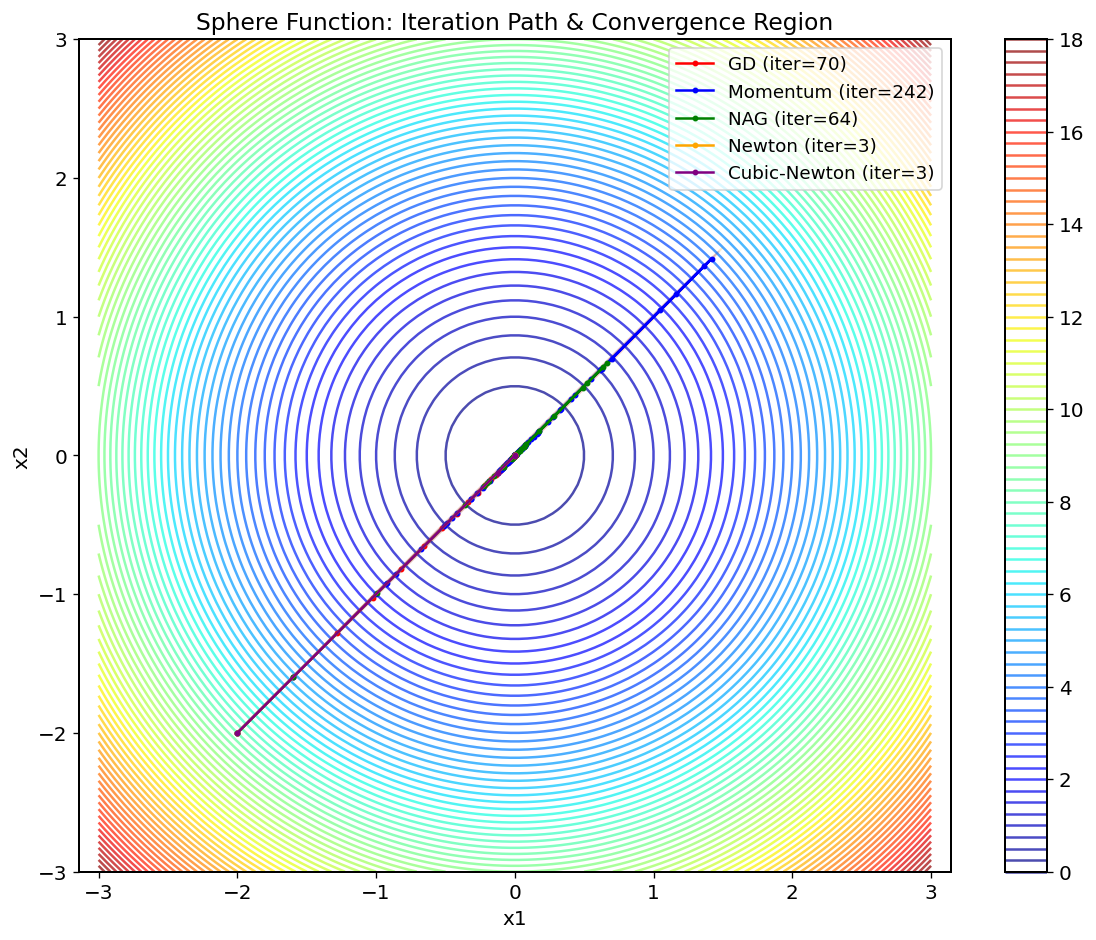

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.optimize import minimize

# ====================== 1. 论文标准测试函数（已修复数组兼容） ======================
def sphere(x):
    """凸单峰函数，最优值0在(0,0)"""
    x = np.asarray(x)
    return np.sum(x ** 2)

def grad_sphere(x):
    x = np.asarray(x)
    return 2 * x

def hess_sphere(x):
    return 2 * np.eye(2)


# ====================== 2. 一阶优化算法：梯度下降系列 ======================
def gradient_descent(f, grad_f, x0, lr=0.1, max_iter=1000, tol=1e-6):
    """标准梯度下降"""
    x = np.asarray(x0, dtype=float)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - lr * g
        path.append(x.copy())
    return x, np.array(path), i+1

def momentum_gd(f, grad_f, x0, lr=0.1, beta=0.9, max_iter=1000, tol=1e-6):
    """动量梯度下降"""
    x = np.asarray(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v + g
        x = x - lr * v
        path.append(x.copy())
    return x, np.array(path), i+1

def nag_gd(f, grad_f, x0, lr=0.1, beta=0.9, max_iter=1000, tol=1e-6):
    """Nesterov加速梯度"""
    x = np.asarray(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x - lr * beta * v)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v + g
        x = x - lr * v
        path.append(x.copy())
    return x, np.array(path), i+1

# ====================== 3. 二阶优化算法：牛顿法 + 三次正则化牛顿法 ======================
def newton_method(f, grad_f, hess_f, x0, max_iter=50, tol=1e-6):
    """经典牛顿法"""
    x = np.asarray(x0, dtype=float)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(x)
        inv_H = np.linalg.inv(H + 1e-3 * np.eye(2))  # 防止奇异
        x = x - inv_H @ g
        path.append(x.copy())
    return x, np.array(path), i+1

def cubic_regularized_newton(f, grad_f, hess_f, x0, sigma=0.1, max_iter=50, tol=1e-6):
    """三次正则化牛顿法（稳定二阶算法）"""
    x = np.asarray(x0, dtype=float)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(x)
        # 三次正则化核心：H + σ||d||I
        def subproblem(d):
            return g @ d + 0.5 * d.T @ H @ d + (sigma / 6) * np.linalg.norm(d) ** 3
        d0 = np.zeros_like(x)
        res = minimize(subproblem, d0, method='BFGS')
        d = res.x
        x = x + d
        path.append(x.copy())
    return x, np.array(path), i+1

# ====================== 4. 绘图函数：等高线 + 迭代路径 + 收敛域（已修复报错） ======================
def plot_contour(f, path_list, names, title, x_range=(-3,3), y_range=(-3,3)):
    # 生成网格
    x = np.linspace(x_range[0], x_range[1], 100)
    y = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(x, y)
    
    # 关键修复：使用向量化计算，避免列表运算报错
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
    
    # 绘制等高线
    plt.figure(figsize=(10, 8))
    plt.contour(X, Y, Z, levels=80, cmap='jet', alpha=0.7)
    plt.colorbar()
    
    # 绘制迭代路径 + 收敛域椭圆
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for idx, (path, name) in enumerate(zip(path_list, names)):
        plt.plot(path[:, 0], path[:, 1], 'o-', color=colors[idx], label=f'{name} (iter={len(path)-1})', markersize=2.5)
        
        # 绘制收敛区域（基于迭代点协方差）
        if len(path) > 2:
            cov = np.cov(path[-20:].T)  # 取最后20个点计算收敛域
            val, vec = np.linalg.eig(cov)
            val = np.maximum(val, 1e-4)
            ell = Ellipse(xy=path[-1], 
                          width=3 * np.sqrt(val[0]), 
                          height=3 * np.sqrt(val[1]),
                          angle=np.rad2deg(np.arctan2(vec[1, 0], vec[0, 0])),
                          color=colors[idx], alpha=0.15)
            plt.gca().add_patch(ell)
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# ====================== 5. 运行实验：Sphere 函数 ======================
if __name__ == "__main__":
    # 统一初始点
    x0 = np.array([-2.0, -2.0])
    
    # 运行算法
    x_gd, path_gd, iter_gd = gradient_descent(sphere, grad_sphere, x0, lr=0.1)
    x_mom, path_mom, iter_mom = momentum_gd(sphere, grad_sphere, x0, lr=0.1)
    x_nag, path_nag, iter_nag = nag_gd(sphere, grad_sphere, x0, lr=0.1)
    x_nt, path_nt, iter_nt = newton_method(sphere, grad_sphere, hess_sphere, x0)
    x_crn, path_crn, iter_crn = cubic_regularized_newton(sphere, grad_sphere, hess_sphere, x0)
    
    # 打印迭代次数对比
    print("="*50)
    print("Sphere 函数迭代次数对比")
    print(f"标准GD: {iter_gd}")
    print(f"动量GD: {iter_mom}")
    print(f"NAG: {iter_nag}")
    print(f"牛顿法: {iter_nt}")
    print(f"三次正则化牛顿: {iter_crn}")
    print("="*50)
    
    # 绘制结果
    plot_contour(
        sphere,
        [path_gd, path_mom, path_nag, path_nt, path_crn],
        ['GD', 'Momentum', 'NAG', 'Newton', 'Cubic-Newton'],
        'Sphere Function: Iteration Path & Convergence Region'
    )




Sphere 函数迭代次数对比
标准GD: 71
动量GD: 243
NAG: 65
牛顿法: 4
三次正则化牛顿: 4


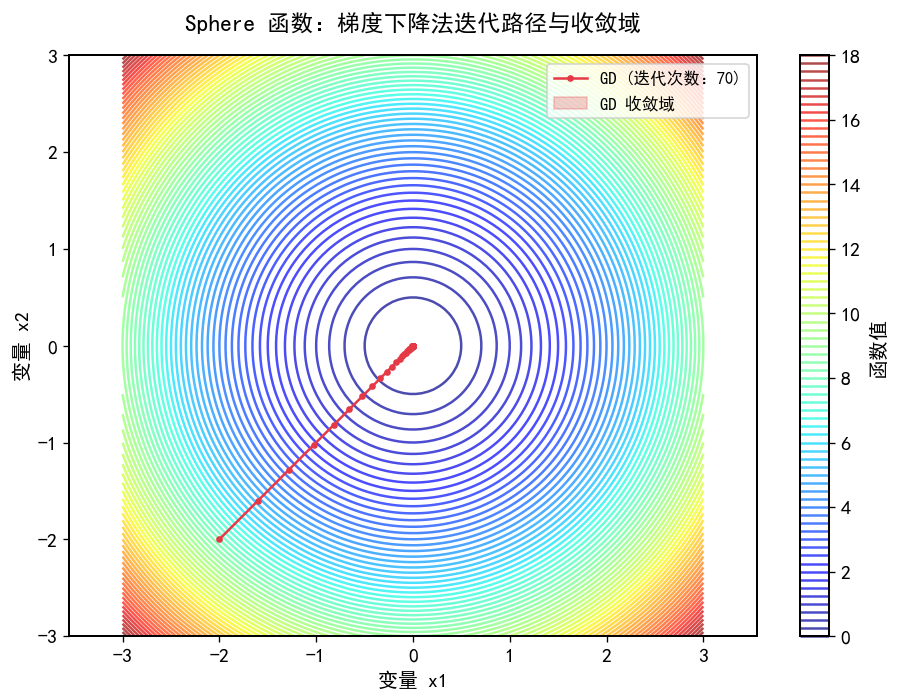

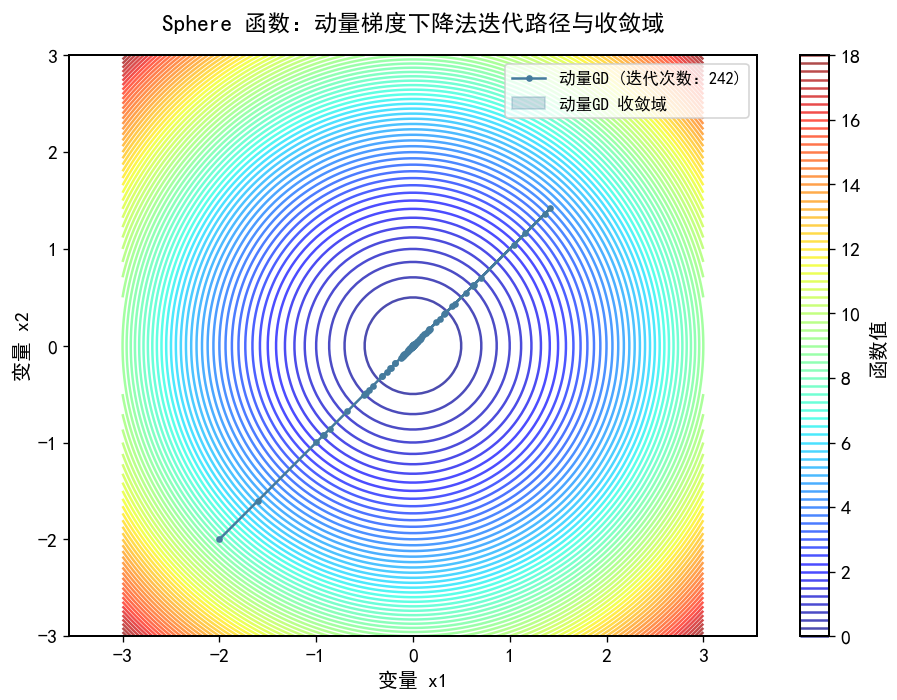

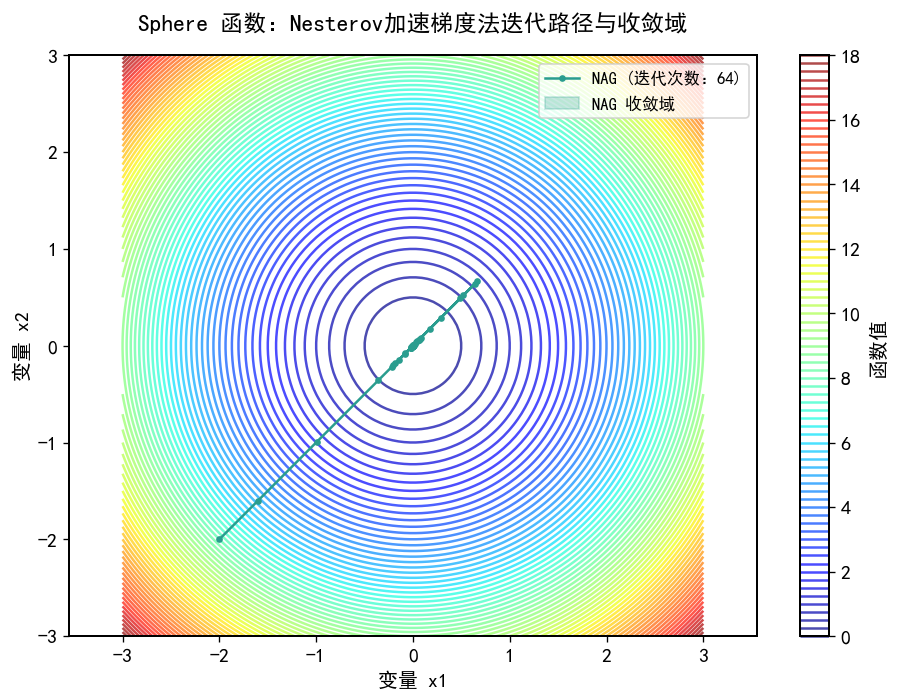

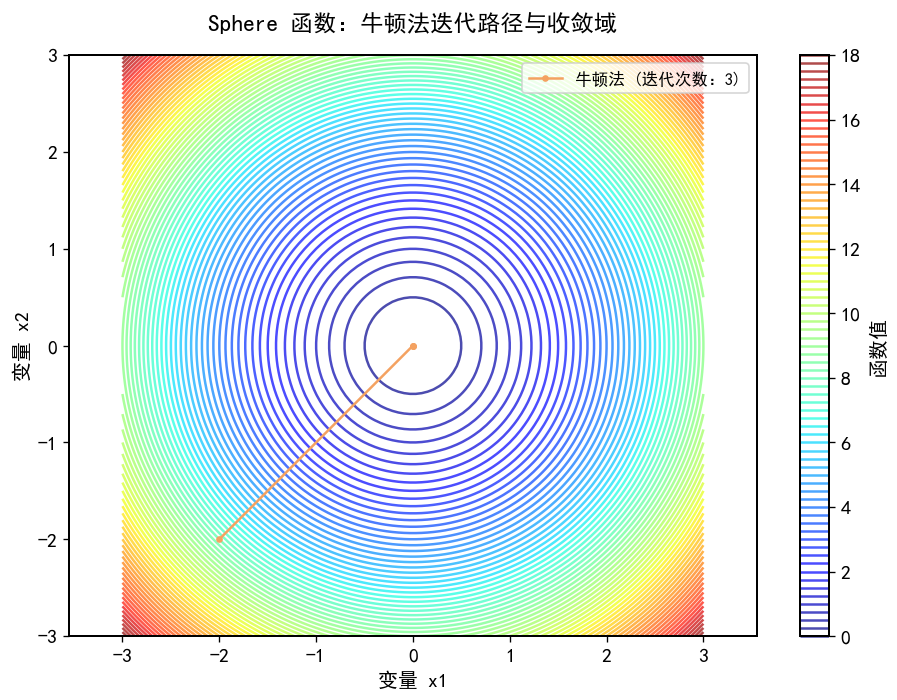

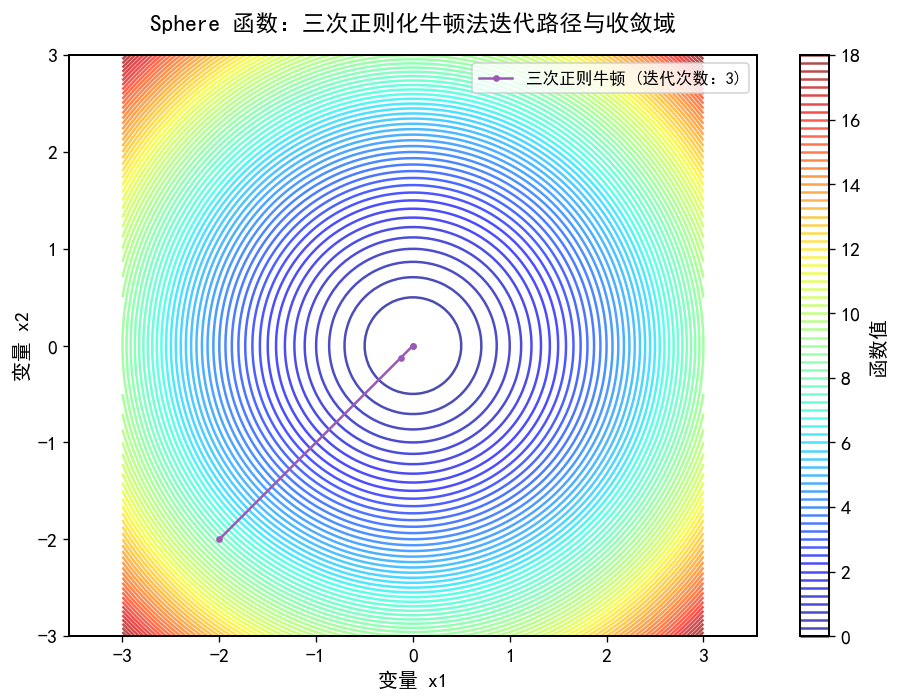

In [4]:
# ====================== 4. 绘图函数：每个算法单独一张图 ======================
def plot_single_contour(f, path, name, title, x_range=(-3,3), y_range=(-3,3)):
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 生成网格
    x = np.linspace(x_range[0], x_range[1], 100)
    y = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(x, y)
    
    # 计算函数值
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
    
    # 绘制画布
    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=80, cmap='jet', alpha=0.7)
    plt.colorbar(label='函数值')
    
    # 绘制迭代路径
    plt.plot(
        path[:, 0], path[:, 1], 
        'o-', color='#E63946' if name == 'GD' else '#457B9D' if name == '动量GD' else '#2A9D8F' if name == 'NAG' else '#F4A261' if name == '牛顿法' else '#9B59B6',
        label=f'{name} (迭代次数：{len(path)-1})', 
        markersize=3, linewidth=1.5
    )
    
    # 绘制收敛区域椭圆
    if len(path) > 5:
        conv_points = path[-15:]
        cov = np.cov(conv_points.T)
        val, vec = np.linalg.eig(cov)
        val = np.maximum(val, 1e-4)
        
        ell = Ellipse(
            xy=path[-1], 
            width=4 * np.sqrt(val[0]), 
            height=4 * np.sqrt(val[1]),
            angle=np.rad2deg(np.arctan2(vec[1, 0], vec[0, 0])),
            color='#E63946' if name == 'GD' else '#457B9D' if name == '动量GD' else '#2A9D8F' if name == 'NAG' else '#F4A261' if name == '牛顿法' else '#9B59B6',
            alpha=0.25, label=f'{name} 收敛域'
        )
        plt.gca().add_patch(ell)
    
    # 中文标签与标题
    plt.xlabel('变量 x1', fontsize=12)
    plt.ylabel('变量 x2', fontsize=12)
    plt.title(title, fontsize=14, pad=15)
    plt.legend(loc='best', fontsize=10)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# ====================== 5. 运行实验：Sphere 函数 ======================
if __name__ == "__main__":
    # 统一初始点
    x0 = np.array([-2.0, -2.0])
    
    # 运行算法
    x_gd, path_gd, iter_gd = gradient_descent(sphere, grad_sphere, x0, lr=0.1)
    x_mom, path_mom, iter_mom = momentum_gd(sphere, grad_sphere, x0, lr=0.1)
    x_nag, path_nag, iter_nag = nag_gd(sphere, grad_sphere, x0, lr=0.1)
    x_nt, path_nt, iter_nt = newton_method(sphere, grad_sphere, hess_sphere, x0)
    x_crn, path_crn, iter_crn = cubic_regularized_newton(sphere, grad_sphere, hess_sphere, x0)
    
    # 打印迭代次数对比
    print("="*50)
    print("Sphere 函数迭代次数对比")
    print(f"标准GD: {iter_gd}")
    print(f"动量GD: {iter_mom}")
    print(f"NAG: {iter_nag}")
    print(f"牛顿法: {iter_nt}")
    print(f"三次正则化牛顿: {iter_crn}")
    print("="*50)
    
    # 分别绘制每个算法的图
    plot_single_contour(sphere, path_gd, 'GD', 'Sphere 函数：梯度下降法迭代路径与收敛域')
    plot_single_contour(sphere, path_mom, '动量GD', 'Sphere 函数：动量梯度下降法迭代路径与收敛域')
    plot_single_contour(sphere, path_nag, 'NAG', 'Sphere 函数：Nesterov加速梯度法迭代路径与收敛域')
    plot_single_contour(sphere, path_nt, '牛顿法', 'Sphere 函数：牛顿法迭代路径与收敛域')
    plot_single_contour(sphere, path_crn, '三次正则牛顿', 'Sphere 函数：三次正则化牛顿法迭代路径与收敛域')

Rosenbrock 函数迭代次数对比
标准GD: 8000
动量GD: 5052
NAG: 5049
牛顿法: 6
三次正则化牛顿: 340


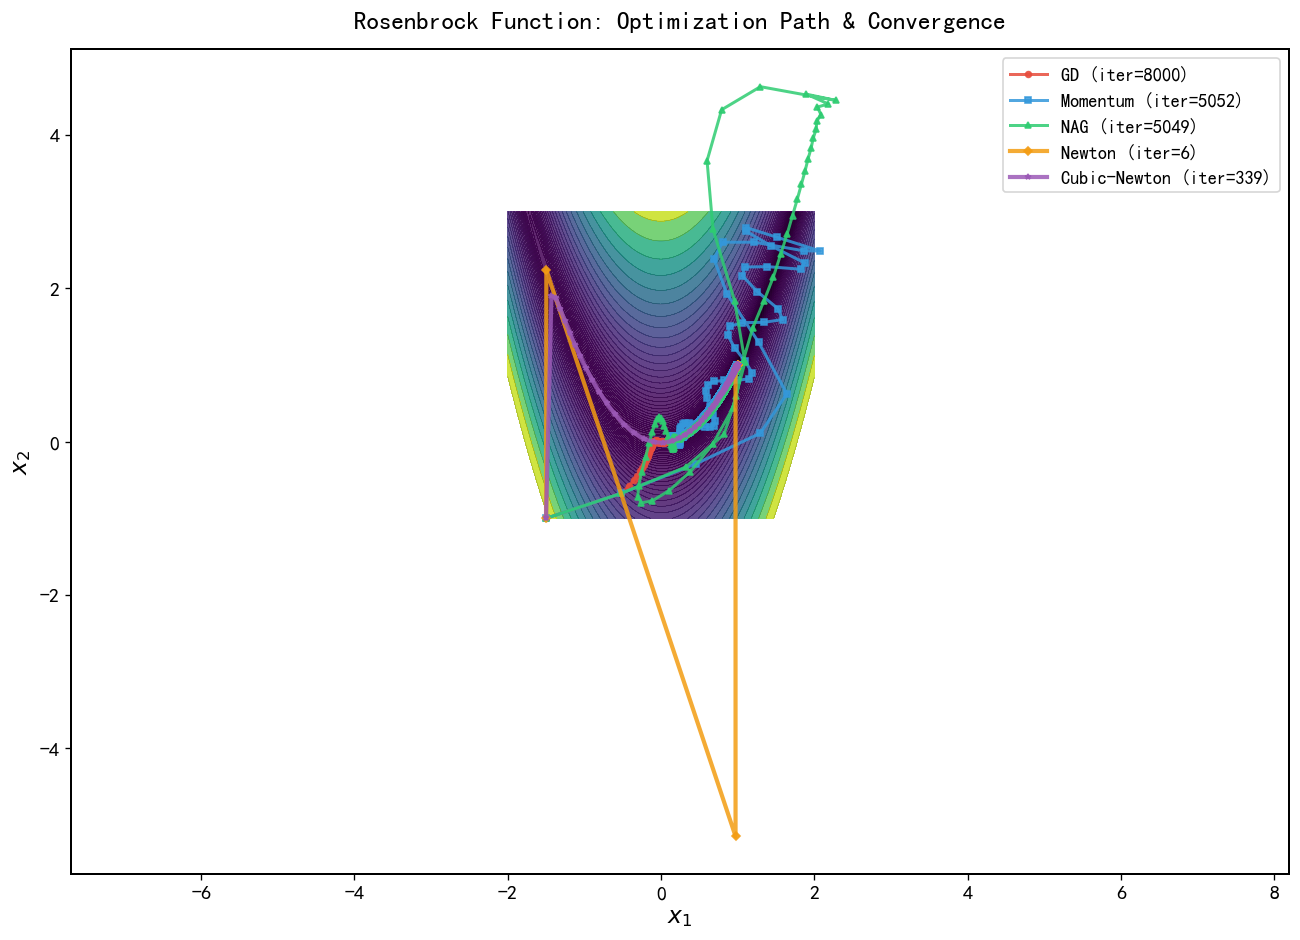

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.optimize import minimize

# ====================== Rosenbrock 函数 ======================
def rosenbrock(x):
    x = np.asarray(x)
    return 100 * (x[1] - x[0] ** 2) ** 2 + (1 - x[0]) ** 2

def grad_rosenbrock(x):
    x = np.asarray(x)
    return np.array([
        -400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0]),
        200 * (x[1] - x[0] ** 2)
    ])

def hess_rosenbrock(x):
    x = np.asarray(x)
    return np.array([
        [1200 * x[0] ** 2 - 400 * x[1] + 2, -400 * x[0]],
        [-400 * x[0], 200]
    ])

# ====================== 一阶优化算法 ======================
def gradient_descent(f, grad_f, x0, lr=0.0005, max_iter=8000, tol=1e-5):
    x = np.asarray(x0, dtype=float)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - lr * g
        if np.isnan(x).any() or np.isinf(x).any():
            break
        path.append(x.copy())
    return x, np.array(path), len(path)-1

def momentum_gd(f, grad_f, x0, lr=0.0005, beta=0.9, max_iter=8000, tol=1e-5):
    x = np.asarray(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v + g
        x = x - lr * v
        if np.isnan(x).any() or np.isinf(x).any():
            break
        path.append(x.copy())
    return x, np.array(path), len(path)-1

def nag_gd(f, grad_f, x0, lr=0.0005, beta=0.9, max_iter=8000, tol=1e-5):
    x = np.asarray(x0, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x - lr * beta * v)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v + g
        x = x - lr * v
        if np.isnan(x).any() or np.isinf(x).any():
            break
        path.append(x.copy())
    return x, np.array(path), len(path)-1

# ====================== 二阶优化算法 ======================
def newton_method(f, grad_f, hess_f, x0, max_iter=1000, tol=1e-6):
    x = np.asarray(x0, dtype=float)
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(x)
        inv_H = np.linalg.inv(H + 1e-3 * np.eye(2))
        x = x - inv_H @ g
        path.append(x.copy())
    return x, np.array(path), len(path)-1

import numpy as np
from scipy.optimize import minimize_scalar

def cubic_regularized_newton(f, grad_f, hess_f, x0, sigma=0.01, max_iter=1000, tol=1e-6):
    x = np.asarray(x0, dtype=float)
    path = [x.copy()]
    
    for i in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
            
        H = hess_f(x)
        
        # --------------- 解析解求解子问题（关键！）---------------
        def phi(t):
            d = -np.linalg.solve(H + t*np.eye(len(x)), g)
            return sigma * np.linalg.norm(d)**3 - 3*t
        
        res = minimize_scalar(phi, bounds=(1e-12, 10), method='bounded')
        t_opt = res.x
        d = -np.linalg.solve(H + t_opt*np.eye(len(x)), g)
        # -------------------------------------------------------
        
        x = x + d
        
        # 防止爆炸
        if np.isnan(x).any() or np.isinf(x).any():
            break
            
        path.append(x.copy())
        
    return x, np.array(path), len(path)

# ====================== ✅ 美化版绘图函数 ======================
def plot_contour_beautiful(f, path_list, names, title, x_range=(-2,2), y_range=(-1,3)):
    plt.rcParams.update({
        'font.size': 12,
        'axes.linewidth': 1.2,
        'figure.dpi': 120,
        'legend.frameon': True,
        'legend.shadow': False,
        'legend.fontsize': 11
    })

    # 网格
    x = np.linspace(x_range[0], x_range[1], 150)
    y = np.linspace(y_range[0], y_range[1], 150)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))

    # 绘图
    fig, ax = plt.subplots(figsize=(11, 8))
    
    # 等高线：柔和配色
    levels = np.logspace(-1, 3, 50)
    cnt = ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.85)
    ax.contour(X, Y, Z, levels=levels, colors='k', linewidths=0.3, alpha=0.3)

    # 高级配色
    colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
    line_widths = [1.8, 1.8, 1.8, 2.5, 2.5]
    markers = ['o', 's', '^', 'D', '*']

    # 画路径
    for idx, (path, name) in enumerate(zip(path_list, names)):
        mask = ~(np.isnan(path).any(axis=1) | np.isinf(path).any(axis=1))
        cp = path[mask]
        if len(cp) < 2:
            continue

        ax.plot(cp[:, 0], cp[:, 1], color=colors[idx], lw=line_widths[idx],
                marker=markers[idx], ms=3.5, alpha=0.85,
                label=f'{name} (iter={len(cp)-1})')

        # 收敛椭圆
        if len(cp) > 10:
            try:
                last = cp[-15:]
                cov = np.cov(last.T)
                val, vec = np.linalg.eig(cov)
                val = np.maximum(val, 1e-4)
                ell = Ellipse(xy=cp[-1],
                              width=4*np.sqrt(val[0]),
                              height=4*np.sqrt(val[1]),
                              angle=np.rad2deg(np.arctan2(vec[1,0], vec[0,0])),
                              color=colors[idx], alpha=0.22)
                ax.add_patch(ell)
            except:
                continue

    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title(title, fontsize=15, pad=12)
    ax.legend(loc='best')
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

# ====================== 运行 ======================
if __name__ == "__main__":
    x0 = np.array([-1.5, -1.0])

    x_gd, path_gd, iter_gd = gradient_descent(rosenbrock, grad_rosenbrock, x0)
    x_mom, path_mom, iter_mom = momentum_gd(rosenbrock, grad_rosenbrock, x0)
    x_nag, path_nag, iter_nag = nag_gd(rosenbrock, grad_rosenbrock, x0)
    x_nt, path_nt, iter_nt = newton_method(rosenbrock, grad_rosenbrock, hess_rosenbrock, x0)
    x_crn, path_crn, iter_crn = cubic_regularized_newton(rosenbrock, grad_rosenbrock, hess_rosenbrock, x0)

    print("="*60)
    print("Rosenbrock 函数迭代次数对比")
    print(f"标准GD: {iter_gd}")
    print(f"动量GD: {iter_mom}")
    print(f"NAG: {iter_nag}")
    print(f"牛顿法: {iter_nt}")
    print(f"三次正则化牛顿: {iter_crn}")
    print("="*60)

    # ✅ 运行美化绘图
    plot_contour_beautiful(
        rosenbrock,
        [path_gd, path_mom, path_nag, path_nt, path_crn],
        ['GD', 'Momentum', 'NAG', 'Newton', 'Cubic-Newton'],
        'Rosenbrock Function: Optimization Path & Convergence'
    )

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# 模型定义
class AllCNN_C(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            nn.Conv2d(96, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            nn.Conv2d(96, 96, 3, stride=2, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Conv2d(96, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            nn.Conv2d(192, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            nn.Conv2d(192, 192, 3, stride=2, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Conv2d(192, 192, 3, padding=0), nn.BatchNorm2d(192), nn.ReLU(),
            nn.Conv2d(192, 192, 1), nn.BatchNorm2d(192), nn.ReLU(),
            nn.Conv2d(192, num_classes, 1)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.view(x.size(0), -1)

# 训练函数
def train(opt_name, lr, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 数据预处理
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761))
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761))
    ])
    train_set = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    test_set = datasets.CIFAR100(root='./data', train=False, transform=transform_test)
    train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

    model = AllCNN_C().to(device)
    criterion = nn.CrossEntropyLoss()

    # 选择优化器
    if opt_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.0)
    elif opt_name == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.99)
    elif opt_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9,0.999), eps=1e-8)
    else:
        raise ValueError

    for epoch in range(1, 351):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            optimizer.step()

        # 评估
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        acc = 100. * correct / total
        print(f"Epoch {epoch:3d} | Test Acc: {acc:.2f}%")

    print(f"Final Test Accuracy: {acc:.2f}%")
    return acc

# 用论文的最佳学习率跑一次
train('adam', 0.000251)

Files already downloaded and verified


KeyboardInterrupt: 

Using device: cpu | Optimizer: SGD
Files already downloaded and verified

Start training SGD for 150 epochs...

Epoch   1/150 | Train Loss: 4.3178 | Test Acc: 6.88%
Epoch   2/150 | Train Loss: 4.0495 | Test Acc: 8.75%
Epoch   3/150 | Train Loss: 3.8807 | Test Acc: 9.32%
Epoch   4/150 | Train Loss: 3.7474 | Test Acc: 10.52%
Epoch   5/150 | Train Loss: 3.6491 | Test Acc: 10.68%
Epoch   6/150 | Train Loss: 3.5474 | Test Acc: 14.80%
Epoch   7/150 | Train Loss: 3.4597 | Test Acc: 12.38%
Epoch   8/150 | Train Loss: 3.3806 | Test Acc: 14.04%
Epoch   9/150 | Train Loss: 3.2948 | Test Acc: 18.53%
Epoch  10/150 | Train Loss: 3.2298 | Test Acc: 16.27%
Epoch  11/150 | Train Loss: 3.1631 | Test Acc: 18.44%
Epoch  12/150 | Train Loss: 3.1068 | Test Acc: 20.98%
Epoch  13/150 | Train Loss: 3.0549 | Test Acc: 18.63%
Epoch  14/150 | Train Loss: 3.0253 | Test Acc: 20.55%
Epoch  15/150 | Train Loss: 2.9780 | Test Acc: 21.83%
Epoch  16/150 | Train Loss: 2.9409 | Test Acc: 16.77%
Epoch  17/150 | Train Loss:

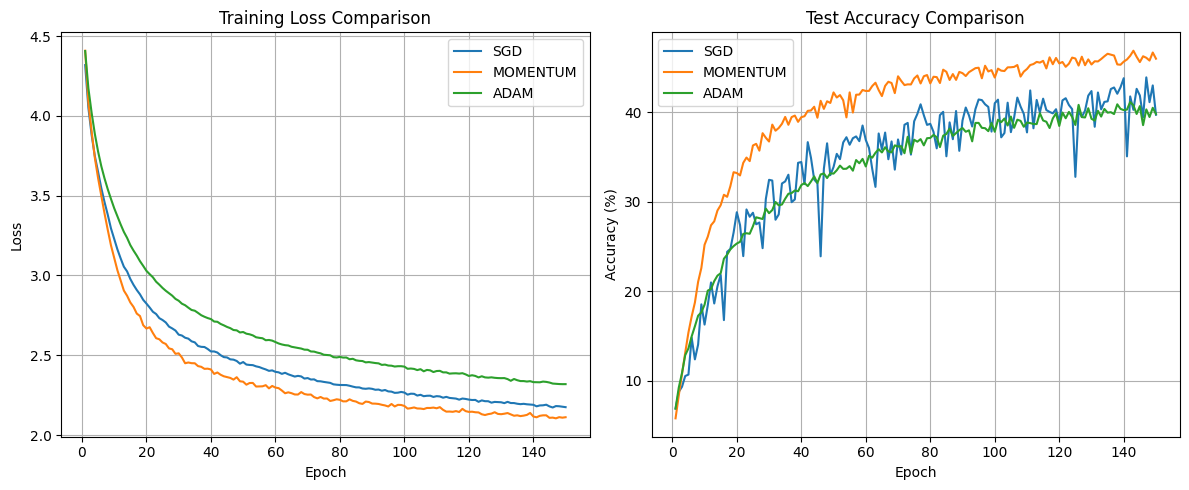

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 模型定义（轻量版，用于快速实验）
class MicroCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Dropout(0.5),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Dropout(0.5),

            nn.Conv2d(64, num_classes, 1)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.view(x.size(0), -1)


def train_one_optimizer(opt_name, lr, num_epochs=150, seed=42):
    """
    训练一个优化器，返回训练损失列表和测试准确率列表
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} | Optimizer: {opt_name.upper()}")

    # 数据预处理（与论文基本一致：随机翻转、裁切、归一化）
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761))
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761))
    ])
    train_set = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    test_set = datasets.CIFAR100(root='./data', train=False, transform=transform_test)
    train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

    model = MicroCNN().to(device)
    criterion = nn.CrossEntropyLoss()

    # 优化器选择（超参数严格按论文 Table 2 设定）
    if opt_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.0)          # 纯 SGD，无动量
    elif opt_name == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.99)        # 动量系数固定为 0.99
    elif opt_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9,0.999), eps=1e-8)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

    train_losses = []
    test_accuracies = []
    print(f"\nStart training {opt_name.upper()} for {num_epochs} epochs...\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)
        avg_train_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # 评估测试集
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        test_acc = 100. * correct / total
        test_accuracies.append(test_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Acc: {test_acc:.2f}%")

    print(f"\n{opt_name.upper()} finished. Final Test Accuracy: {test_acc:.2f}%\n")
    return train_losses, test_accuracies


if __name__ == "__main__":
    # 学习率严格采用论文中 CIFAR-100 实验的最佳值（Table 2）
    configs = [
        ('sgd',       0.158),      # α = 1.58e‑01
        ('momentum',  0.00398),    # α = 3.98e‑03, μ = 0.99
        ('adam',      0.000251)    # α = 2.51e‑04
    ]

    all_losses = {}
    all_accs = {}

    for opt, lr in configs:
        losses, accs = train_one_optimizer(opt, lr, num_epochs=150, seed=42)
        all_losses[opt] = losses
        all_accs[opt] = accs

    # 在同一张图上绘制比较曲线
    epochs = range(1, 151)
    plt.figure(figsize=(12, 5))

    # 训练损失对比
    plt.subplot(1, 2, 1)
    for opt in all_losses:
        plt.plot(epochs, all_losses[opt], label=opt.upper())
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True)

    # 测试准确率对比
    plt.subplot(1, 2, 2)
    for opt in all_accs:
        plt.plot(epochs, all_accs[opt], label=opt.upper())
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Test Accuracy Comparison')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('optimizer_comparison.png')
    plt.show()

In [11]:
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.optim import Optimizer
from deepobs.pytorch.runners import StandardRunner

# ===================== 设备配置模块 =====================
def get_training_device() -> torch.device:
    device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"训练设备: {device_available}")
    
    if torch.cuda.is_available():
        current_idx = torch.cuda.current_device()
        device_name = torch.cuda.get_device_name(current_idx)
        print(f"CUDA 设备索引: {current_idx}, 设备名称: {device_name}")
    else:
        print("未检测到 CUDA，自动切换至 CPU 训练")
    
    return device_available

DEVICE = get_training_device()

# ===================== 实验运行封装 =====================
def execute_experiment(optimizer_cls, param_config, param_values, dataset_name, epochs=20, batch=256):
    original_argv = sys.argv.copy()
    sys.argv = [""]
    
    try:
        runner = StandardRunner(optimizer_cls, param_config)
        runner.run(
            testproblem=dataset_name,
            hyperparams=param_values,
            num_epochs=epochs,
            batch_size=batch,
            print_train_iter=False,
            tb_log=False,
            device=DEVICE
        )
    finally:
        sys.argv = original_argv
    
    return runner

# ===================== LION 优化器实现（已修复 DeepOBS 兼容） =====================
class LION(Optimizer):
    # 关键修复：把 lr 改成 learning_rate，和 DeepOBS 对齐
    def __init__(self, params, learning_rate=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        if not 0.0 <= learning_rate:
            raise ValueError(f"Invalid learning rate: {learning_rate}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        defaults = dict(lr=learning_rate, betas=betas, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss_value = None
        if closure is not None:
            with torch.enable_grad():
                loss_value = closure()

        for param_group in self.param_groups:
            lr = param_group["lr"]
            beta1, beta2 = param_group["betas"]
            decay = param_group["weight_decay"]

            for param in param_group["params"]:
                if param.grad is None:
                    continue

                grad = param.grad
                if decay != 0:
                    grad.add_(param, alpha=decay)

                state = self.state[param]
                if not state:
                    state["exp_avg"] = torch.zeros_like(param)

                exp_moving_avg = state["exp_avg"]
                update_direction = exp_moving_avg.mul(beta1).add(grad, alpha=1 - beta1)
                exp_moving_avg.mul_(beta2).add_(grad, alpha=1 - beta2)
                param.add_(torch.sign(update_direction), alpha=-lr)

        return loss_value

# ===================== 超参数与实验配置 =====================
lion_parameter_config = {
    "learning_rate": {"type": float, "default": 1e-4},  # 这里也改成 learning_rate
    "betas": {"type": tuple, "default": (0.9, 0.99)},
}

OPTIMIZER_LIST = [
    ("LION", LION, lion_parameter_config, {"learning_rate": 5e-3, "betas": (0.9, 0.9)}),
]

DATASET_TASKS = ["cifar10_3c3d"]
TRAIN_EPOCHS = 20
BATCH_SIZE = 256

# ===================== 主实验流程 =====================
experiment_results = {}

for dataset in DATASET_TASKS:
    experiment_results[dataset] = {}
    
    for opt_name, opt_cls, hp_cfg, hp_val in OPTIMIZER_LIST:
        print(f"\n===== 正在运行 {opt_name} | 数据集: {dataset} =====")
        trained_runner = execute_experiment(
            optimizer_cls=opt_cls,
            param_config=hp_cfg,
            param_values=hp_val,
            dataset_name=dataset,
            epochs=TRAIN_EPOCHS,
            batch=BATCH_SIZE
        )
        
        experiment_results[dataset][opt_name] = trained_runner.logs
        log_data = trained_runner.logs

        if "test_accuracies" in log_data and len(log_data["test_accuracies"]) > 0:
            final_acc = log_data["test_accuracies"][-1]
            print(f"【最终测试准确率】: {final_acc:.2f}%")
        else:
            final_loss = log_data["test_losses"][-1]
            print(f"【最终测试损失】: {final_loss:.4f}")

# ===================== 训练损失曲线可视化 =====================
num_datasets = len(DATASET_TASKS)
fig, ax_list = plt.subplots(1, num_datasets, figsize=(6 * num_datasets, 4))
if num_datasets == 1:
    ax_list = [ax_list]

for idx, dataset in enumerate(DATASET_TASKS):
    ax = ax_list[idx]
    for optimizer in experiment_results[dataset]:
        losses = experiment_results[dataset][optimizer]["train_losses"]
        ax.plot(losses, label=optimizer)
    
    ax.set_title(f"{dataset} - 训练损失曲线")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("训练损失对比", fontsize=14)
plt.tight_layout()
plt.show()

# ===================== 测试准确率曲线可视化 =====================
for dataset in DATASET_TASKS:
    first_opt = next(iter(experiment_results[dataset]))
    if "test_accuracies" in experiment_results[dataset][first_opt]:
        plt.figure()
        for optimizer in experiment_results[dataset]:
            accs = experiment_results[dataset][optimizer]["test_accuracies"]
            plt.plot(accs, label=optimizer)
        
        plt.title(f"{dataset} - 测试准确率曲线")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

# ===================== 最终结果表格 =====================
performance_summary = {}
for dataset in DATASET_TASKS:
    performance_summary[dataset] = {}
    for optimizer in experiment_results[dataset]:
        log = experiment_results[dataset][optimizer]
        if "test_accuracies" in log and len(log["test_accuracies"]) > 0:
            performance_summary[dataset][optimizer] = f"{log['test_accuracies'][-1]:.2f}%"
        else:
            performance_summary[dataset][optimizer] = f"{log['test_losses'][-1]:.4f}"

result_df = pd.DataFrame(performance_summary).T
print("\n" + "=" * 30)
print("           最终性能对比表")
print("=" * 30)
print(result_df)

训练设备: cpu
未检测到 CUDA，自动切换至 CPU 训练

===== 正在运行 LION | 数据集: cifar10_3c3d =====
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
********************************
Evaluating after 0 of 20 epochs...
TRAIN: loss 3.5856, acc 0.101863
VALID: loss 3.58997, acc 0.096655
TEST: loss 3.58659, acc 0.099960
********************************


KeyboardInterrupt: 